# Solución problema de la varilla usando _Programación Dinámica_

Librerías necesarias

In [6]:
import random
import time
import math
import matplotlib.pyplot as plt

### Tamaños de varilla y precios empleados para mediciones

In [7]:
tamaños = [1, 10, 1000, 2000, 2500]
precios = [1]

for i in range(2, 2501):
    aumento = random.randint(1, 6)
    nuevo_precio = precios[-1] + aumento
    precios.append(nuevo_precio)

## 1. Solución usando recursividad

In [8]:
def cutRod(p, n):
    if n == 0:
        return 0, []
    q = -math.inf
    best_pieces = []
    for i in range(n):
        val, pieces = cutRod(p, n - i - 1)
        val += p[i]
        if val > q:
            q = val
            best_pieces = [i + 1] + pieces
    return q, best_pieces

## 1.1 Análisis de complejidad temporal del algoritmo recursivo

### idea general  
Las instrucciones simples del algoritmo, como:
- asignaciones
- comparaciones
- accesos a arreglos
- sumas
- returns
tienen costo constante:
$$\Theta(1)$$
El costo total estará dominado por:
- el bucle
- las llamadas recursivas

### Análisis del algoritmo  
### Ciclo for  
El número de iteraciones del bucle
```
for i in range(n):
 ...
```
realiza exactamente $n$ iteraciones.  

### Llamadas recursivas
En cada iteración aparece una llamada recursiva:
```
cutRod(p, n - i - 1)
```
Los tamaños de las subllamadas son:
$$n-1, n-2, n-3, ..., 0$$
Por tanto, el tiempo total satisface:
$$T(n) = T(n-1) + T(n-2) + ... + T(0) + bn$$
donde:
- $bn$ representa el costo adicional del bucle y operaciones constantes
- cada llamada recursiva genera nuevas expansiones porque no existe memoización
Ahora:
$$T(n) = T(n-1) + T(n-2) + ... + T(0) + bn$$
para $n-1$:
$$T(n-1) = T(n-2) + T(n-3) + ... + T(0) + b(n-1)$$
Restando ambas ecuaciones:
$$T(n) - T(n-1) = T(n-1) + b$$
Por tanto:
$$T(n) = 2T(n-1) + b$$
La constante b no afecta el orden dominante, así que se obtiene:
$$T(n) = 2T(n-1) + b$$
La recurrencia presenta la forma:
$$T(n) = aT(n-c) + bn^k$$
Identificando los parámetros:

| Parámetro | Valor | Justificación |
|-----------|-----------|-----------|
| a    | 2    | aparecen dos copias dominantes de T(n-1)    |
| c    | 1   | el tamaño disminuye en una unidad    |
| k    | 0    | el término adicional es constante    |

José L. Balcázar en "Apuntes sobre el cálculo de la eficiencia de los algoritmos" establece:
$$
T(n) \in
\begin{cases}
\Theta(n^k) & a < 1 \\
\Theta(n^{k+1}) & a = 1 \\
\Theta(a^{n/c}) & a > 1
\end{cases}
$$

En este caso:
$$a = 2 > 1$$
Por tanto aplica el tercer caso:
$$T(n) \in \Theta(a^{n/c})$$
Sustituyendo:
$$T(n) \in \Theta(2^n)$$

### Complejidad final  
La complejidad final del algoritmo recursivo es:
$$\Theta(2^n)$$

## 1.2 Tiempo de ejecución para diferentes tamaños de varilla

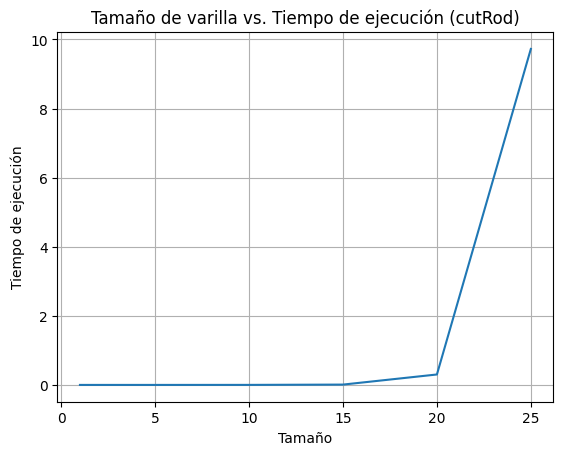

In [9]:
# Medición de tiempos
n = [1, 5, 10, 15, 20, 25]
p = [1]

for i in range(2, 26):
    aumento = random.randint(1, 6)
    nuevo_precio = p[-1] + aumento
    p.append(nuevo_precio)

tiempos = []
for j in n:
    t0 = time.time()
    cutRod(p, j)
    t1 = time.time()
    tiempoFinal = t1 - t0
    tiempos.append(tiempoFinal)
    
plt.plot(n, tiempos)
plt.title("Tamaño de varilla vs. Tiempo de ejecución (cutRod)")
plt.xlabel("Tamaño")
plt.ylabel("Tiempo de ejecución")
plt.grid()
plt.show()

## 2. Solución usando el enfoque Memoización Top Down

In [10]:
def memoizedCutRodAux(p, n, r, s):
    if r[n] >= 0:
        return r[n]
    if n == 0:
        q = 0
    else:
        q = -math.inf
        for i in range(n):
            val = p[i] + memoizedCutRodAux(p, n - i - 1, r, s)
            if val > q:
                q = val
                s[n] = i + 1
    r[n] = q
    return q

def memoizedCutRod(p, n):
    r = [-math.inf] * (n + 1)
    s = [0] * (n + 1)
    memoizedCutRodAux(p, n, r, s)
    
    pieces = []
    rem = n
    while rem > 0:
        pieces.append(s[rem])
        rem -= s[rem]
    return r[n], pieces

# test
p = [1, 5, 8, 9, 10, 17, 17, 20, 24, 30]
print(memoizedCutRod(p, 7))

(18, [1, 6])


## 2.1 Análisis de complejidad temporal del algoritmo memoizedCutRod

### Función auxiliar memoizedCutRodAux:  
### idea general:
Las instrucciones simples del algoritmo, como:
- asignaciones
- comparaciones
- accesos a arreglos
- operaciones aritméticas
- returns 

tienen costo constante:
$$\Theta(1)$$
    
Por lo que no dominan el costo total. El tiempo final estará determinado por las estructuras repetitivas y las llamadas recursivas.  
El fragmento relevante es:  
```
for i in range(n):
    val = p[i] + memoizedCutRodAux(p, n-i-1, r, s)
``` 
### Bucle
El bucle realiza $n$ iteraciones.  
Sin memoización, cada iteración generaría nuevas expansiones recursivas. Sin embargo, el arreglo r almacena resultados previamente calculados, lo que implica que cada subproblema se calcula una sola vez.  
Durante la primera llamada a:
$$T(n)$$
La única expansión recursiva real ocrrure hacia:
$$T(n-1)$$
Porque dicha llamada termina calculando también:
$$T(n-2), T(n-3),...,T(0)$$
y deja todos esos valores almacenados en memoria.  
Por tanto:
- La primera llamada recursiva cuesta: 
$$T(n-1) + bn$$
- Las demás llamadas del bucle son recuperaciones desde caché:
$$\Theta(1)$$
El resto de operaciones del ciclo también son constantes, por lo que el costo total adicional del bucle es lineal:
$$\Theta(n)$$
    
La función auxiliar satisface entonces:
$$T(n) = T(n-1) + bn$$
Esta recurrencia corresponde al caso de decrecimiento aritmético:
$$T(n) = aT(n-c) + bn^k$$
Identificando parámetros:  

| Parámetro | Valor | Justificación |
|-----------|-----------|-----------|
| a    | 1    | existe una única expansión recursiva real    |
| c    | 1   | el tamaño disminuye en una unidad    |
| k    | 1    | el costo adicional del bucle es lineal    |

Según José L. Balcázar en "Apuntes sobre el cálculo de la eficiencia de los algoritmos" establece:
$$
T(n) \in
\begin{cases}
\Theta(n^k) & a < 1 \\
\Theta(n^{k+1}) & a = 1 \\
\Theta(a^{n/c}) & a > 1
\end{cases}
$$
Como:
$$a = 1$$
y
$$k = 1$$
aplica el segundo caso:
$$T(n) \in \Theta(n^{k+1})$$
Por tanto:
$$T(n) \in \Theta(n^2)$$

### Función principal memoizedCutRod:
La función principal realiza:
1. Inicialización de arreglos de tamaño n:
$$\Theta(n)$$
2. Llamada a memoizedCutRodAux:
$$\Theta(n^2)$$
3. Reconstrucción de la solución mediante un ciclo while:
En el peor caso, el while ejecuta n iteraciones, por lo que cuesta:
$$\Theta(n)$$

### Complejidad total
Aplicando la regla de la suma de José L. Balcázar:
$$\Theta(f + g) = \Theta(max(f,g))$$
el término dominante es:
$$\theta(n^2)$$
Por tanto, la complejidad temporal final del algoritmo principal es:
$$\theta(n^2)$$

## 2.2 Tiempo de ejecución para diferentes tamaños de varilla

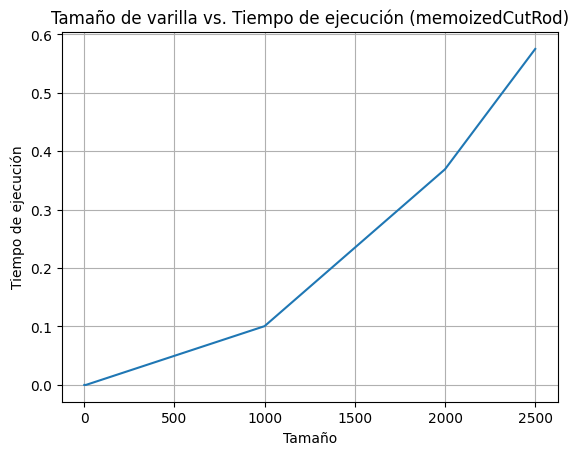

In [11]:
# Medición de tiempos

tiempos = []
for j in tamaños:
    t0 = time.time()
    memoizedCutRod(precios, j)
    t1 = time.time()
    tiempoFinal = t1 - t0
    tiempos.append(tiempoFinal)
    
plt.plot(tamaños, tiempos)
plt.title("Tamaño de varilla vs. Tiempo de ejecución (memoizedCutRod)")
plt.xlabel("Tamaño")
plt.ylabel("Tiempo de ejecución")
plt.grid()
plt.show()

## 3. Solución usando el enfoque Iterativo bottomUpCutRod

In [12]:
def bottomUpCutRod(p, n):
    r = [0] * (n + 1)
    s = [0] * (n + 1)
    r[0] = 0
    for j in range(1, n + 1):
        q = -math.inf
        for i in range(j):
            val = p[i] + r[j - i - 1]
            if val > q:
                q = val
                s[j] = i + 1
        r[j] = q
    
    pieces = []
    rem = n
    while rem > 0:
        pieces.append(s[rem])
        rem -= s[rem]
    return r[n], pieces

# test
p = [1, 5, 8, 9, 10, 17, 17, 20, 24, 30]
print(bottomUpCutRod(p, 7))

(18, [1, 6])


## 3.1 Análisis de complejidad temporal del algoritmo bottomUpCutRod

### Idea general  
Las instrucciones simples del algoritmo, como:
- asignaciones
- comparaciones
- accesos a arreglos
- operaciones aritméticas
- returns  
tienen costo constante:
$$\Theta(1)$$
En este algoritmo no hay llamadas recursivas, por lo que el análisis se realiza únicamente sumando el costo de los ciclos.  
Las instrucciones:
```
r = [0] * (n+1)
s = [0] * (n+1)
```
crean arreglos de tamaño
$$n+1$$
Por tanto, cada inicialización cuesta:
$$\Theta(n)$$
Por regla de la suma, el costo conjunto es:
$$\Theta(n)$$

### Análisis del doble bucle
El fragmento principal es:
```
for j in range(1, n + 1):
    q = -math.inf

    for i in range(j):
        val = p[i] + r[j - i - 1]

        if val > q:
            q = val
            s[j] = i + 1

    r[j] = q
```
El ciclo externo se ejecuta $n$ veces.
Para cada valor de $j$, el ciclo interno:
```
for i in range(j):
```
realiza exactamente $j$ iteraciones.  
Las operaciones dentro del ciclo tienen un costo:
$$\Theta(1)$$
Por tanto, una iteración del ciclo interno cuesta:
$$\Theta(1)$$
y el ciclo interno completo cuesta:
$$\Theta(j)$$

### Suma total del doble ciclo
El costo total del algoritmo dinámico es:
$$\sum_{j=1}^{n} \Theta(j)$$
Sacando la constante:
$$\Theta(\sum_{j=1}^{n} j)$$
Usando la suma conocida:
$$\sum_{j=1}^{n} j = \frac{n(n+1)}{2}$$
Obtenemos:
$$\Theta(\frac{n(n+1)}{2})$$
El término dominante es:
$$\Theta(n^2)$$
Por tanto, el doble ciclo cuesta:
$$\Theta(n^2)$$

### Análisis del while final
El fragmento:
```
while rem > 0:
    pieces.append(s[rem])
    rem -= s[rem]
```
reconstruye la solución.  
En el peor caso:
```
s[rem] = 1
```
en cada iteración, entonces:
$$rem = n, n-1, n-2,...,1$$
y el ciclo ejecuta $n$ iteraciones.  
Cada vuelta realiza operaciones constantes, entonces el costo por iteración es:
$$\Theta(1)$$
El costo total es:
$$\Theta(n)$$

### Complejidad total
Sumando todos los costos:

| Parte | Complejidad |
|-----------|-----------|
| Inicialización de arreglos    | $\Theta(n)$    |
| Doble ciclo principal    | $\Theta(n^2)$   |
| While final    | $\Theta(n)$    |

Aplicando la regla de la suma, el término dominante es:
$$\Theta(n^2)$$

### Resultado final
La complejidad temporal del algoritmo bottomUpCutRod es:
$$\Theta(n^2)$$


## 3.2 Tiempos de ejecución con diferentes tamaños de varilla

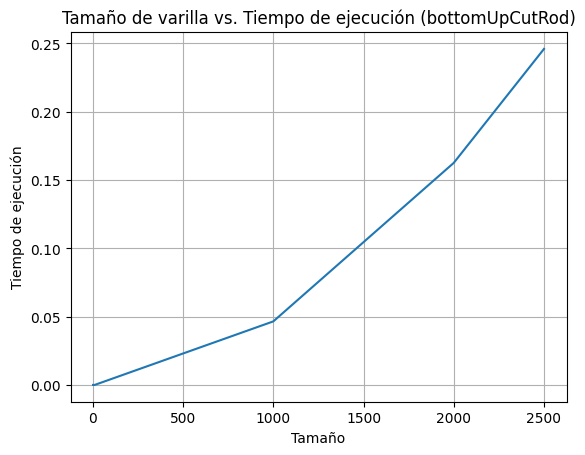

In [13]:
# Medición de tiempos

tiempos = []
for j in tamaños:
    t0 = time.time()
    bottomUpCutRod(precios, j)
    t1 = time.time()
    tiempoFinal = t1 - t0
    tiempos.append(tiempoFinal)
    
plt.plot(tamaños, tiempos)
plt.title("Tamaño de varilla vs. Tiempo de ejecución (bottomUpCutRod)")
plt.xlabel("Tamaño")
plt.ylabel("Tiempo de ejecución")
plt.grid()
plt.show()